# PedSilicoICH: Part 1. Phantoms

This notebook introduces the features and uses of the PedSilicoICH tool for generating anthropomorphic ground truth phantoms - currently based on the MIDA phantom and NIHPD MR brain atlases as a base - with models of intracranial hemorrhage, specifically intraparenchymal (IPH), epiural (EDH), and subural (SDH) hemorrages.liver metastases.

This notebook also introduces concepts of the `Phantoms` Class

## Select a starting phantom

In [1]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'LVO MIDA Head': functools.partial(<class 'InSilicoLVO.phantoms.LVO_MIDA'>, phantom_dir='/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/MIDA_Head_Phantom'),
 '0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial

In [2]:
phantom = available_phantoms['38.0 yr MIDA Head']()
phantom.resize(3*[240], mode='nearest')
phantom.insert_lesion('EDH', mass_effect=True, seed=42, intensity=80, volume=60, edema=1,
                      texture_args=dict(noise_type='perlin', contrast_std=2))


        Phantom Class: MIDA_Head
        Age (years): 38.0
        Shape (voxels): (240, 240, 175)
        Size (mm): (239.96, 240.0, 175.0)
        
        Number of lesions: 1
        Lesion locations [voxel index (z, x, y)]: [(80, 73, 128)]
        Mass effect: True
        

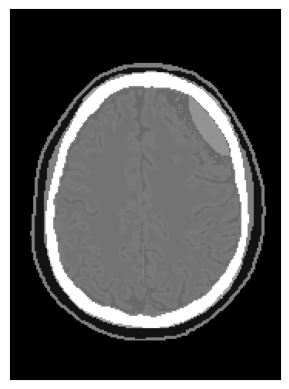

In [3]:
from utils import ctshow
ctshow(phantom.get_CT_number_phantom()[63])

In [4]:
phantom = available_phantoms['38.0 yr MIDA Head']()
phantom.resize(3*[240], mode='nearest')
phantom.insert_lesion('IPH', mass_effect=True, seed=42, intensity=80, volume=10, edema=1,
                      texture_args=dict(noise_type='perlin', contrast_std=2))


        Phantom Class: MIDA_Head
        Age (years): 38.0
        Shape (voxels): (240, 240, 175)
        Size (mm): (239.96, 240.0, 175.0)
        
        Number of lesions: 1
        Lesion locations [voxel index (z, x, y)]: [(np.int64(65), np.int64(97), np.int64(63))]
        Mass effect: True
        

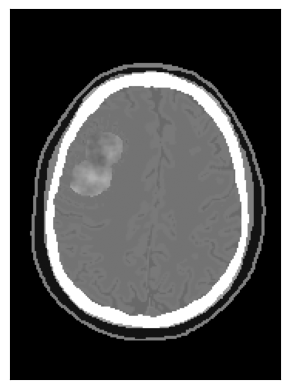

In [5]:
from utils import ctshow
ctshow(phantom.get_CT_number_phantom()[63])

%pip install -q ipywidgets

In [6]:
import matplotlib.pyplot as plt
from utils import scrollview

scrollview(phantom.get_CT_number_phantom())

interactive(children=(IntSlider(value=120, description='idx', max=239), Output()), _dom_classes=('widget-inter…

## define a set of lesions to insert
This can be done individual or arranged into a list if inserting multiple as demonstrated here.

In [7]:
import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(70, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)
lesions

[{'volume': np.float64(0.05),
  'intensity': np.float64(70.0),
  'lesion_type': 'IPH',
  'seed': 336},
 {'volume': np.float64(0.275),
  'intensity': np.float64(60.0),
  'lesion_type': 'IPH',
  'seed': 336},
 {'volume': np.float64(0.5),
  'intensity': np.float64(50.0),
  'lesion_type': 'IPH',
  'seed': 336}]

## Insert the lesions into the selected phantom

In [8]:
for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/3:
{'volume': np.float64(0.05), 'intensity': np.float64(70.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 1/3:
{'volume': np.float64(0.275), 'intensity': np.float64(60.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 2/3:
{'volume': np.float64(0.5), 'intensity': np.float64(50.0), 'lesion_type': 'IPH', 'seed': 336}




        Phantom Class: MIDA_Head
        Age (years): 38.0
        Shape (voxels): (240, 240, 175)
        Size (mm): (239.96, 240.0, 175.0)
        
        Number of lesions: 4
        Lesion locations [voxel index (z, x, y)]: [(np.int64(65), np.int64(97), np.int64(63)), (np.int64(77), np.int64(139), np.int64(78)), (np.int64(76), np.int64(104), np.int64(51)), (np.int64(76), np.int64(82), np.int64(75))]
        Mass effect: False
        

Checkout the results

In [9]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


TODO: Next add some simple options to add random amounts of scale, controlling decay factor of mass effect and contrast_std

Contrast STD (heterogeneity) related to time since stroke 

Decay/strength of mass effect related to swelling/edema etc

Also add some unit tests for mass effect

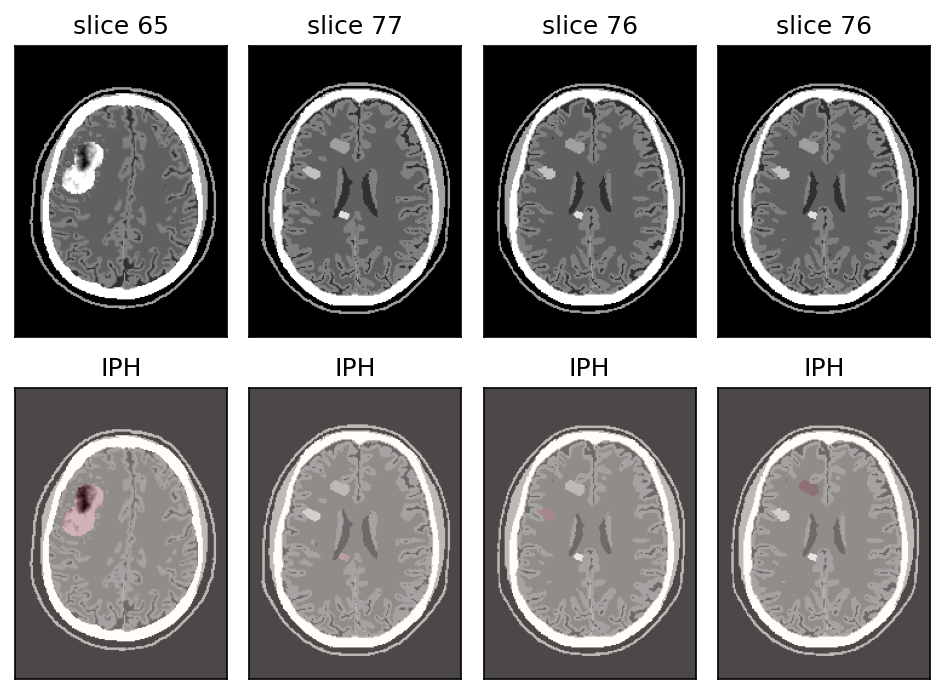

In [10]:
from utils import scrollview, show_lesions
show_lesions(phantom, 'brain')

In [11]:
# pip install -q noise

In [12]:
scrollview(phantom.get_CT_number_phantom())

interactive(children=(IntSlider(value=120, description='idx', max=239), Output()), _dom_classes=('widget-inter…

In [13]:
phantom.get_sutures?

Object `phantom.get_sutures` not found.


In [14]:
import matplotlib.pyplot as plt
if hasattr(phantom, 'get_sutures'):
    sutures = phantom.get_sutures()
    f, axs = plt.subplots(1, 3)
    for dim, ax in enumerate(axs.flatten()):
        ax.imshow(sutures.max(axis=dim))

Some simple analytical geometric lesions are included in the module `lesion_insertion`, see the help string for more details

In [15]:
phantom = available_phantoms['38.0 yr MIDA Head']()
phantom


        Phantom Class: MIDA_Head
        Age (years): 38.0
        Shape (voxels): (480, 480, 350)
        Size (mm): (239.96, 240.0, 175.0)
        
        Number of lesions: 0
        Lesion locations [voxel index (z, x, y)]: []
        Mass effect: False
        

In [16]:
phantom.insert_lesion('EDH', volume=1)


        Phantom Class: MIDA_Head
        Age (years): 38.0
        Shape (voxels): (480, 480, 350)
        Size (mm): (239.96, 240.0, 175.0)
        
        Number of lesions: 1
        Lesion locations [voxel index (z, x, y)]: [(174, 135, 268)]
        Mass effect: False
        

Need to revisit mass effect for NIHPD and UNC to make sure its working there too

[]

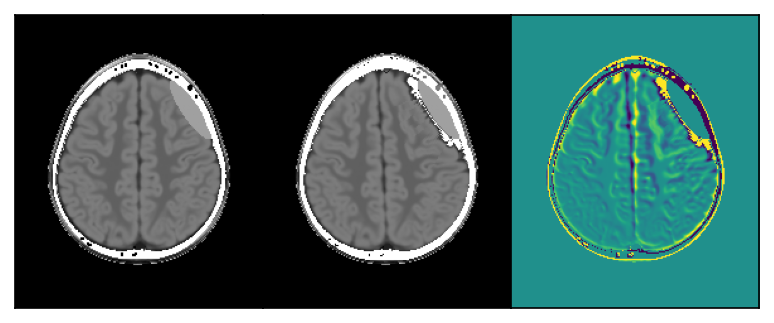

In [17]:
from utils import ctshow, load_phantom

seed = 42
age = 6.5
vol = 20
display = 'brain'

phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=vol, mass_effect=False, seed=seed)

phantom_me = load_phantom(age)
phantom_me.insert_lesion('EDH', volume=vol, mass_effect=True, seed=seed)
phantom_no_me_image = phantom.get_CT_number_phantom()[phantom._lesion_coords[0][0]]
phantom_me_image = phantom_me.get_CT_number_phantom()[phantom_me._lesion_coords[0][0]]

f, axs = plt.subplots(1, 3, dpi=150, gridspec_kw=dict(hspace=0, wspace=0))
ctshow(phantom.get_CT_number_phantom()[phantom._lesion_coords[0][0]], display, fig=f, ax=axs[0])
ctshow(phantom_me.get_CT_number_phantom()[phantom_me._lesion_coords[0][0]], display, fig=f, ax=axs[1])
axs[2].imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
axs[2].set_xticks([])
axs[2].set_yticks([])

Each lesion type has its own specific method, `add_<lesion_type>`, checkout the help string of each for more details

### Intraparenchymal (round)

In [18]:
phantom.add_round_lesion?

Signature:
phantom.add_round_lesion(
    volume: int = 10,
    intensity: int = 50,
    material: str = 'white matter',
    eccentricity: float = 0.5,
    mass_effect: bool | float = 0.5,
    edema: bool | int = False,
    complexity: int = 3,
    overlap: float = 0.4,
    seed: int | None = None,
    texture_args: dict | None = None,
    **kwargs,
) -> tuple
Docstring:
Adds a round lesion to an image in a random location.

This function inserts a lesion, potentially with complex characteristics,
into a specified material region of an image. It allows for detailed
customization of the lesion's shape, intensity, and secondary effects
like edema or mass effect.

Args:
    volume (int | list[int]): The volume of the sphere lesion in mL. If a
        list is provided, it will create concentric lesions.
    intensity (int | list[int]): The intensity of the sphere lesion in
        Hounsfield Units (HU). If a list is provided, it will create
        concentric lesions with the corresponding 

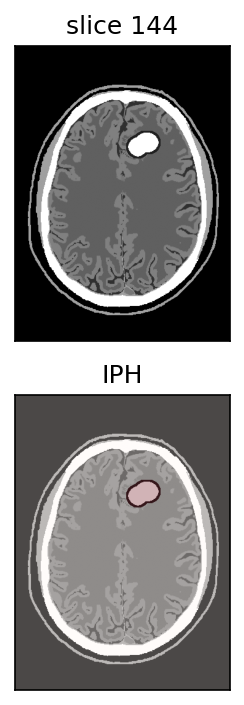

In [19]:
volume = 6
intensity = 100
phantom = load_phantom(38.0)
phantom.resize(shape=phantom.shape, mode='nearest')
phantom.insert_lesion('IPH', volume, intensity=intensity, complexity=3, edema=7, eccentricity=0.1, mass_effect=True) 
show_lesions(phantom)

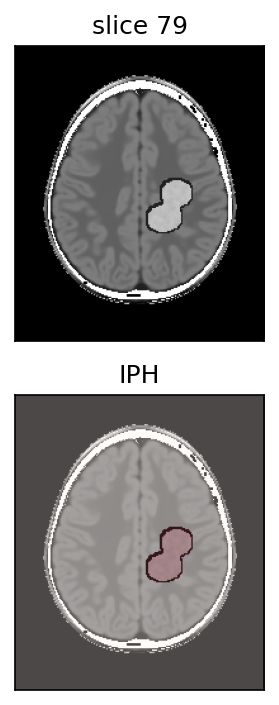

In [20]:
volume = 6
intensity = 60
phantom = load_phantom(age)
phantom.insert_lesion('IPH', volume=volume, intensity=intensity,
                      complexity=3, edema=4, eccentricity=0.1, mass_effect=False,
                      texture_args=dict(noise_type='perlin', scale=5, contrast_std=0.1), seed=42) 
show_lesions(phantom)

### Subdural (SDH)

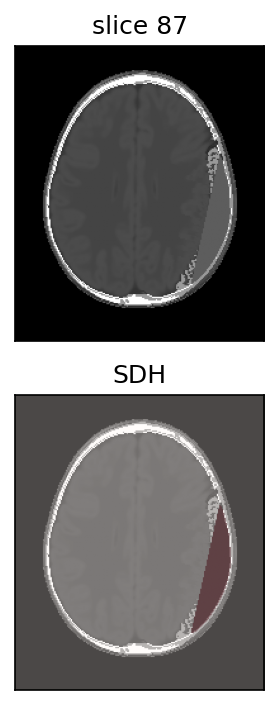

In [21]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('SDH', volume, intensity=intensity, mass_effect=True) 
show_lesions(phantom, 'subdural')

### Epidural (EDH)

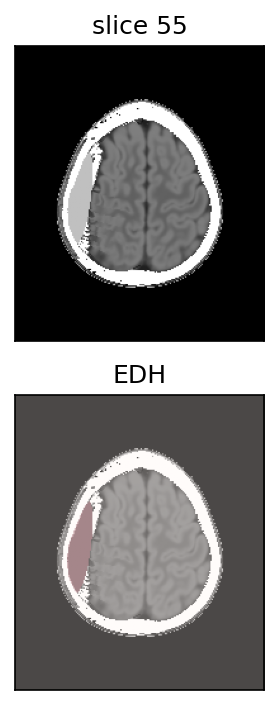

In [22]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume, intensity=intensity, mass_effect=True) 
show_lesions(phantom, 'brain')

### Multiple (TODO: ensure no overlapping of hemorrhages)

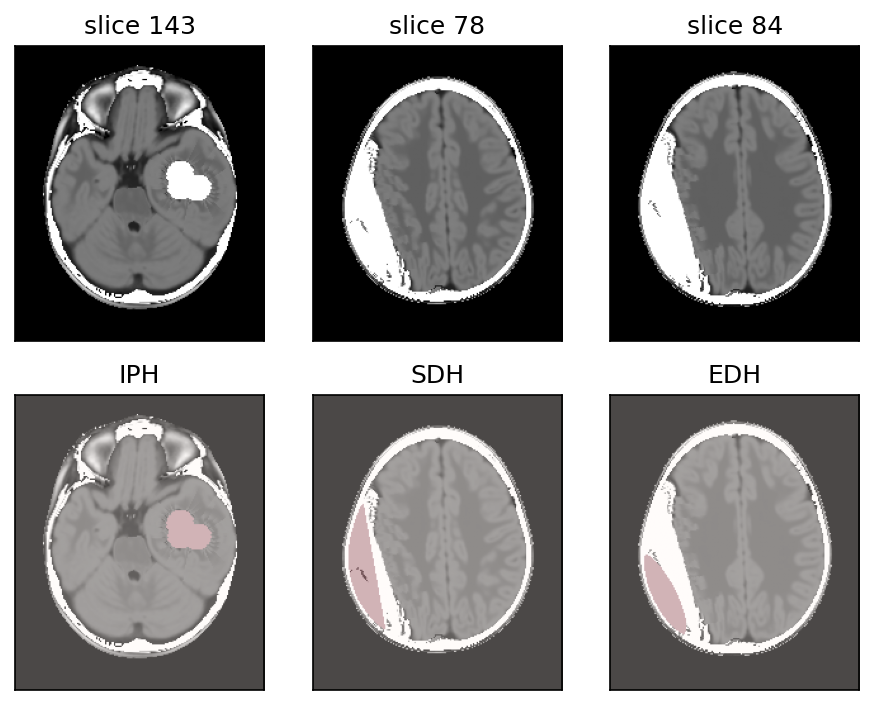

In [23]:
seed = 32
mass_effect = True
phantom = load_phantom(age)
intensity = 100
phantom.insert_lesion('IPH', volume=3, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('SDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('EDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 

show_lesions(phantom,'brain')

In [24]:
phantom


        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(np.int64(143), np.int64(102), np.int64(140)), (78, 138, 40), (84, 161, 42)]
        Mass effect: True
        

In [25]:
lesions = phantom.get_lesion_mask()
lesions.shape

(189, 233, 197)

`phantom._lesion_coords` is a list of (z,x,y) coordinates of the inserted lesion, you can check the `len` to see how many lesions have been inserted, thus by indexing `[0][0]` we are taking the z index of the first lesion.

In [26]:
phantom._lesion_coords

[(np.int64(143), np.int64(102), np.int64(140)), (78, 138, 40), (84, 161, 42)]

Note that rerunning the following cell, you can keep adding lesions to a phantom

In [27]:
from monai.transforms import RandAffine

add_positioning_augmentation = True
if add_positioning_augmentation:
    positioning_transform = RandAffine(prob=1, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")
else:
    positioning_transform = RandAffine(prob=0)

phantom.apply_transform(positioning_transform)

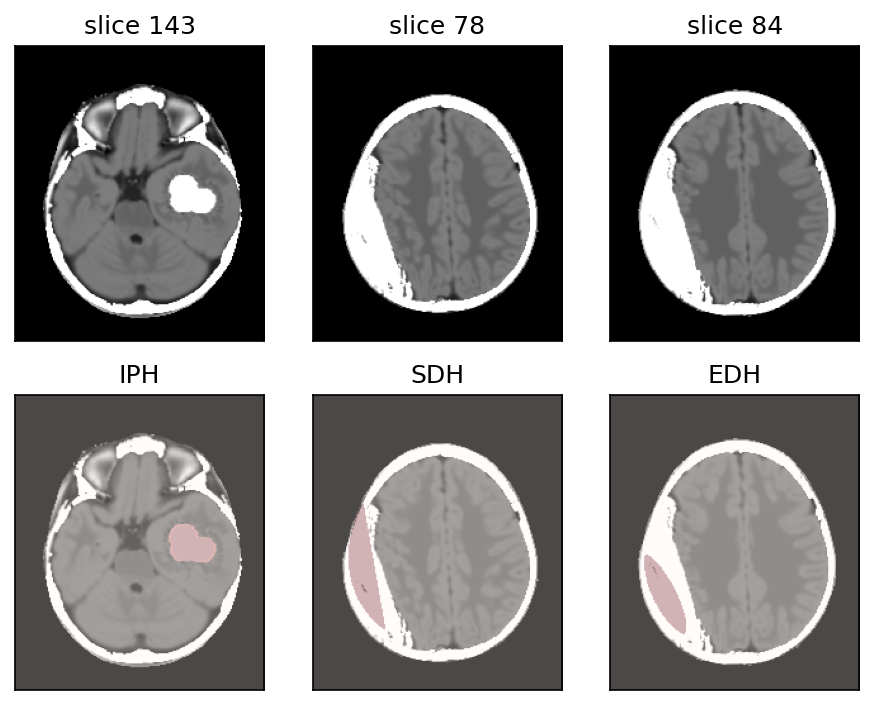

In [28]:
phantom.apply_transform(positioning_transform)
show_lesions(phantom)

Note: there is some misalignment of the mask and image when there are more than 1 lesion, the first lesion mask gets transformed, but the second is untouched. This is a TODO to fix this such that all inserted lesion masks get transformed.